In [ ]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf


In [25]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter 
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
import os
import requests

In [37]:
load_dotenv(override=True)
import json
# llm = ChatOpenAI(
#     model="gpt-4o", 
#     api_key=os.getenv("github_OPENAI_KEY"), 
#     base_url="https://models.inference.ai.azure.com" 
# )
api_key = os.getenv("open_router_key")

llm = ChatOpenAI(
    model="openai/gpt-4o",
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1/chat/completions",
)


# # Make sure the key includes "Bearer " prefix
# headers = {
#     "Authorization": f"Bearer {api_key}",  # ✅ Add Bearer prefix
#     "Content-Type": "application/json"
# }

# response = requests.post(
#     url="https://openrouter.ai/api/v1/chat/completions",
#     headers=headers,
#     data=json.dumps({
#         "model": "openai/gpt-4o",  # Note: gpt-5.2 doesn't exist
#         "messages": [
#             {
#                 "role": "user",
#                 "content": "What is the meaning of life?"
#             }
#         ]
#     })
# )

# print(f"Status: {response.status_code}")
# print(f"Response: {response.json()}")


try:
    print("Testing Updated GitHub Token...")
    print("Response:", llm.invoke("Hello!").content)
except Exception as e:
    print(f"Error: {e}")

Testing Updated GitHub Token...
Error: Error code: 404 - {'error': {'message': 'Not Found', 'code': 404}}


In [15]:
# this is to load a pdf file
loader = PyPDFLoader("Intro_to_ML.pdf")
docs = loader.load()

parsing for Object Streams


In [17]:
len(docs)

39

In [18]:
# Check if your documents have any text content
print(f"Total documents: {len(docs)}")

# Check first few documents for content
for i, doc in enumerate(docs[:5]):  # Check first 5 docs
    content_length = len(doc.page_content)
    print(f"Document {i}: {content_length} characters")
    if content_length > 0:
        print(f"  Preview: {doc.page_content[:100]}...")
    else:
        print(f"  ⚠️ Document {i} is EMPTY")
        
# Check if ANY document has content
docs_with_content = [doc for doc in docs if doc.page_content.strip()]
print(f"\nDocuments with actual content: {len(docs_with_content)} out of {len(docs)}")

Total documents: 39
Document 0: 0 characters
  ⚠️ Document 0 is EMPTY
Document 1: 1391 characters
  Preview: Introduction to  
Machine learning
The goal of this chapter is to take you through the Machine learn...
Document 2: 1782 characters
  Preview: Introduction to Machine learning
[ 2 ]
• Machine learning subfields: supervised learning, unsupervis...
Document 3: 2408 characters
  Preview: Chapter 1
[ 3 ]
Definition
Let's start with defining what Machine learning is. There are many techni...
Document 4: 2284 characters
  Preview: Introduction to Machine learning
[ 4 ]
The primary goal of a Machine learning implementation is to d...

Documents with actual content: 38 out of 39


In [19]:
#this is to split pages of the given book into multile chunks

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [20]:
len(chunks)

84

In [21]:
# this will create embeddings of given chunks and make a vector store
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
vector_store = FAISS.from_documents(chunks, embeddings)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [68]:
vector_store

In [69]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [70]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [71]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [72]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [73]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [74]:
tool_node = ToolNode(tools)

In [75]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

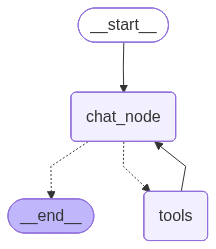

In [76]:
chatbot

In [ ]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [80]:
print(result['messages'][-1].content)

To find the ideal value of \( K \) in the k-nearest neighbors (k-NN) algorithm, follow these steps:

1. **Understand the Role of \( K \)**: The parameter \( K \) represents the number of nearest neighbors to consider when making predictions. A small \( K \) can lead to a model that is sensitive to noise in the data, whereas a large \( K \) can smooth out the decision boundary too much, potentially leading to underfitting.

2. **Choose a Parameter Selection Method**: The most common method for selecting the ideal \( K \) is through grid search, which involves trying a range of values for \( K \) and evaluating their performance. You can use cross-validation to assess the performance of each \( K \).

3. **Set Up Cross-Validation**: Divide your dataset into training and testing subsets, and then perform k-fold cross-validation. This involves splitting the training set into \( K \) smaller sets. For each unique group, you will:
   - Train your model using the other \( K - 1 \) sets.
   - 